# DATASET

## mass: stellar mass in units of solar mass.
## luminosity: stellar luminosity in units of solar luminosity.

In [10]:
mass = [0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4]

luminosity = [0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0]

# Stellar Luminosity Hands-On

## 1. Environment Setup

In [11]:
%pip install numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
### Import required libraries

import numpy as np
import matplotlib.pyplot as plt

## Loading the dataset as NumPy arrays.

In [13]:
mass = np.array(mass)
luminosity = np.array(luminosity)

##  Shapes and ranges of the variables.

In [14]:
massShape = mass.shape
massRange = np.arange(massShape[0])
luminosityShape = luminosity.shape
luminosityRange = np.arange(luminosityShape[0])
print("Mass shape:", massShape)
print("Mass range:", massRange)
print("Luminosity shape:", luminosityShape)
print("Luminosity range:", luminosityRange)

Mass shape: (10,)
Mass range: [0 1 2 3 4 5 6 7 8 9]
Luminosity shape: (10,)
Luminosity range: [0 1 2 3 4 5 6 7 8 9]


## Ploting 

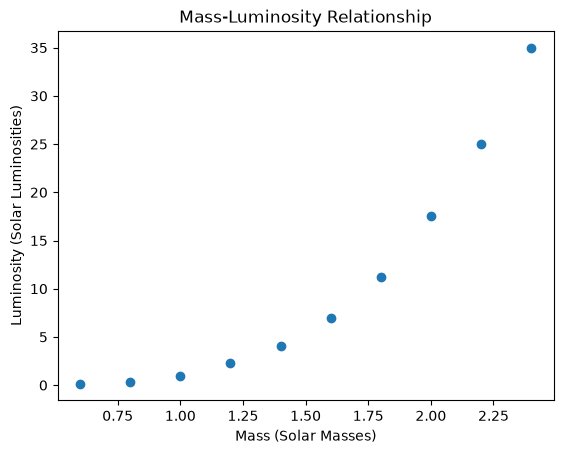

In [15]:
plt.figure()
plt.plot(mass, luminosity, 'o')
plt.xlabel('Mass (Solar Masses)')
plt.ylabel('Luminosity (Solar Luminosities)')
plt.title('Mass-Luminosity Relationship')
plt.yticks(np.arange(0, 40, 5))
plt.show()

The graph shows a nonlinear relationship where luminosity increases at an increasing rate as stellar mass increases.

## Linear Model Suitability

A straight line does not appear to be adequate because it cannot accurately follow the nonlinear trend of the data. As a result, the linear regression model would produce systematic errors, especially for observations with higher stellar masses.   

## Implementing the learning algorithm

In [16]:
def prediction(x, w, b):
    # Placeholder for the learning algorithm implementation
    y_hat = x @ w + b
    return y_hat

## Mean squared error

In [17]:
def meanSquaredError(y_hat, y_true):
    m=y_true.shape[0]
    return 1/(2 * m) * np.sum((y_hat - y_true) ** 2)

## Gradient 

In [18]:
def gradient(x, y, w, b):
    m = y.shape[0]
    predictions = prediction(x, w, b)
    error = predictions - y
    dw = (x.T @ error) / m
    db = 1/m * np.sum(error)

    return dw, db

## Gradient descent  

In [19]:
def gradientDescent(x, y, w_init, b_init, alpha, num_iterations):
    w = w_init
    b = b_init
    cost_history = []

    for i in range(num_iterations):
        dw, db = gradient(x, y, w, b)

        w = w - alpha * dw
        b = b - alpha * db

        cost_history.append(meanSquaredError(prediction(x, w, b), y))

    return w, b, cost_history

## Training model

In [22]:
X_linear = mass.reshape(-1, 1)
w_init = np.array([0.0])
b_init = 0.0
learning_rate = 0.01
num_iterations = 1000
w, b, cost_history = gradientDescent(X_linear, luminosity, w_init, b_init, learning_rate, num_iterations)


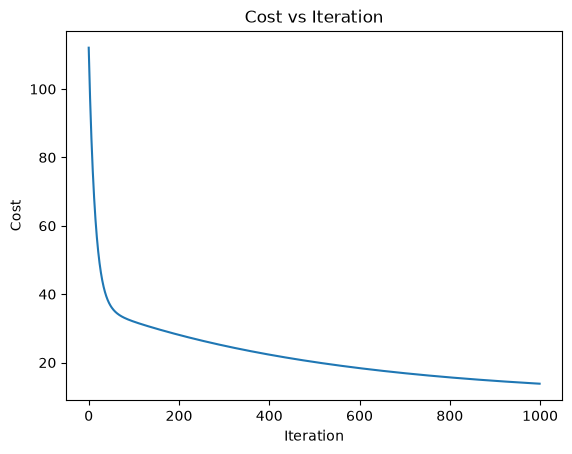

In [23]:
plt.figure()
plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost vs Iteration")
plt.show()

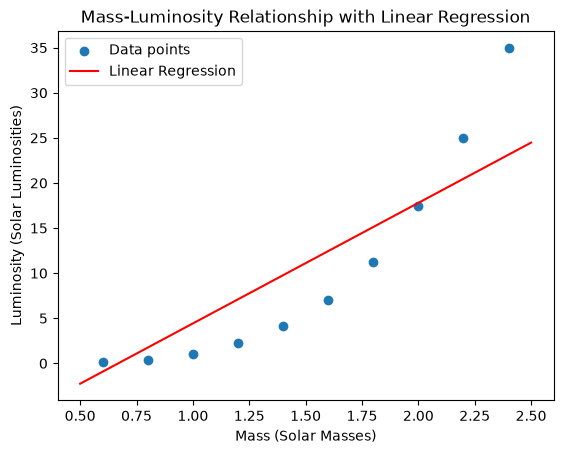

In [29]:
plot_x = np.linspace(0.5, 2.5, 100).reshape(-1, 1)
plot_y = prediction(plot_x, w, b)   
plt.figure()
plt.scatter(mass, luminosity, label='Data points')
plt.plot(plot_x, plot_y, label='Linear Regression', color='red')
plt.xlabel('Mass (Solar Masses)')
plt.ylabel('Luminosity (Solar Luminosities)')
plt.title('Mass-Luminosity Relationship with Linear Regression')
plt.legend()
plt.show()
